<a href="https://colab.research.google.com/github/dequiroz/1MTR53_RobIA/blob/main/03_Cinem%C3%A1tica_Robots_moviles/02_Modelo_robot_diferencial_taller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://drive.google.com/uc?export=view&id=1FsTa2YzWwxY-HBkd2EOXAlkPJ1zpikWv" alt="drawing" width="150"/>


<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1VBn7nKlruxCPLHH_UuD8B2pkvKP7JLRd" alt="drawing" width="800"/>


</br>

<img src="https://drive.google.com/uc?export=view&id=1tpg1CJh4or-VMrY-Qip25hgedgwy1Y8-" alt="drawing" width="800"/>
</p>


# Simulación con modelo cinemático del Robot Diferencial
* **Responsable del material:** Diego Quiroz Velasquez
* Pontificia Universidad Católica del Perú
* Sección Ingeniería Mecatrónica

---
> **Descripción:**
> Este archivo sirve como complemento práctico a los conceptos teóricos revisados en clase, enlazando la **Cinemática Directa** de un robot móvil diferencial. Al finalizar este cuaderno, serás capaz de entender la aplicación de cinemática directa para simulaciones de movimiento.

<details>
<summary><b>Historial de Versiones del Documento (Hacer clic para desplegar)</b></summary>

<br>

| Versión | Fecha | Autor / Rol | Descripción del Cambio |
| :---: | :---: | :--- | :--- |
| **v1.0** | 11/09/2026 | Diego Quiroz | Estructuración inicial de cinemática para vehiculo diferencial. |

---
</details>
<br>

<img src="https://drive.google.com/uc?export=view&id=1vgFoFHEKMN0WcAFlKS2hPMg2KuBm3sp9" alt="drawing"/>

# Modelo cinemático del robot diferencial

Este notebook implementa y simula el **modelo cinemático de un robot móvil diferencial**, presentado en la lectura previa a esta sesión.

Un robot diferencial controla, de forma independiente, la velocidad angular de su rueda izquierda ($\dot\theta_l$) y de su rueda derecha ($\dot\theta_r$). A partir de esas dos velocidades, la lectura mostró que la velocidad lineal $v$ y angular $\omega$ del robot se obtienen como:

$$
v = \frac{r(\dot\theta_r + \dot\theta_l)}{2} \qquad\qquad \omega = \frac{r(\dot\theta_r - \dot\theta_l)}{2b}
$$

donde $r$ es el radio de las ruedas y $2b$ la distancia entre ellas. Una vez obtenidas $v$ y $\omega$, el movimiento del punto medio del eje de ruedas sigue el mismo modelo cinemático visto en la lectura:

$$
\dot{x} = v \cos\varphi \qquad \dot{y} = v \sin\varphi \qquad \dot{\varphi} = \omega
$$

Este sistema **no tiene solución cerrada** para perfiles arbitrarios de $\dot\theta_r(t)$ y $\dot\theta_l(t)$ (restricción no holonómica), por lo que se resuelve mediante **integración numérica**.

**Objetivo de la sesión:** comprender, mediante código, cómo las velocidades que realmente se comandan a un robot diferencial —las de cada rueda, típicamente a través de sus motores— determinan la trayectoria completa del robot en el plano.

> **Nota:** la siguiente clase se formalizará la restricción de rodadura sin deslizamiento de cada rueda por separado, y se derivarán estas mismas ecuaciones a partir de dicha restricción, además de extender el análisis a robots omnidireccionales.


## 1. Importar librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = True


## 2. Integración de Euler

La idea de la integración de Euler es simple: si se conoce la velocidad de un sistema en el instante $t$, se puede estimar su posición un pequeño intervalo $\Delta t$ después, asumiendo que la velocidad se mantiene aproximadamente constante durante ese intervalo:

$$
x_{k+1} = x_k + \dot{x}_k \cdot \Delta t
$$

Aplicando esto a las tres ecuaciones cinemáticas, en cada paso $k$:

$$
x_{k+1} = x_k + v_k \cos(\varphi_k)\, \Delta t
$$
$$
y_{k+1} = y_k + v_k \sin(\varphi_k)\, \Delta t
$$
$$
\varphi_{k+1} = \varphi_k + \omega_k \, \Delta t
$$

donde $v_k$ y $\omega_k$ se calculan, en cada paso, a partir de las velocidades de rueda comandadas en ese instante. Cuanto más pequeño es $\Delta t$, más precisa es la aproximación, pero se requieren más pasos de cálculo.


## 3. De velocidades de rueda a velocidades del robot

Antes de integrar, se implementa la relación algebraica entre las velocidades angulares de las ruedas y las velocidades $v$, $\omega$ del robot. Esta es la misma ecuación de la lectura previa; aquí se traduce directamente a código.


In [ ]:
def diferencial_a_v_omega(theta_dot_r, theta_dot_l, r, b):
    """
    Convierte velocidades angulares de las ruedas de un robot diferencial
    en velocidad lineal (v) y angular (omega) del robot.

    Parámetros
    ----------
    theta_dot_r, theta_dot_l : float
        Velocidad angular de la rueda derecha e izquierda [rad/s]
    r : float
        Radio de las ruedas [m]
    b : float
        Semidistancia entre las ruedas [m] (distancia total entre ruedas = 2b)

    Retorna
    -------
    v : float      - velocidad lineal del robot [m/s]
    omega : float  - velocidad angular del robot [rad/s]
    """
    v = r * (theta_dot_r + theta_dot_l) / 2.0
    omega = r * (theta_dot_r - theta_dot_l) / (2.0 * b)
    return v, omega


## 4. Implementación del simulador del robot diferencial

In [ ]:
def simular_robot_diferencial(theta_dot_r_func, theta_dot_l_func, r, b,
                               estado_inicial=(0.0, 0.0, 0.0),
                               dt=0.05, t_final=10.0):
    """
    Simula la cinemática de un robot diferencial mediante integración de Euler,
    comandando directamente las velocidades angulares de cada rueda.

    Parámetros
    ----------
    theta_dot_r_func, theta_dot_l_func : function
        Funciones theta_dot(t) -> velocidad angular comandada a cada rueda [rad/s]
    r : float
        Radio de las ruedas [m]
    b : float
        Semidistancia entre las ruedas [m]
    estado_inicial : tuple (x0, y0, phi0)
        Pose inicial del robot [m, m, rad]
    dt : float
        Paso de integración [s]
    t_final : float
        Tiempo total de simulación [s]

    Retorna
    -------
    t : np.ndarray - vector de tiempo
    x, y, phi : np.ndarray - trayectoria del robot
    v_hist, omega_hist : np.ndarray - v, omega resultantes en cada paso
    thetadot_r_hist, thetadot_l_hist : np.ndarray - velocidades de rueda comandadas
    """
    n_pasos = int(t_final / dt)
    t = np.zeros(n_pasos + 1)
    x = np.zeros(n_pasos + 1)
    y = np.zeros(n_pasos + 1)
    phi = np.zeros(n_pasos + 1)
    v_hist = np.zeros(n_pasos + 1)
    omega_hist = np.zeros(n_pasos + 1)
    thetadot_r_hist = np.zeros(n_pasos + 1)
    thetadot_l_hist = np.zeros(n_pasos + 1)

    x[0], y[0], phi[0] = estado_inicial

    for k in range(n_pasos):
        td_r = theta_dot_r_func(t[k])
        td_l = theta_dot_l_func(t[k])
        v_k, omega_k = diferencial_a_v_omega(td_r, td_l, r, b)

        thetadot_r_hist[k] = td_r
        thetadot_l_hist[k] = td_l
        v_hist[k] = v_k
        omega_hist[k] = omega_k

        # --- Ecuaciones cinemáticas del robot diferencial (integración de Euler) ---
        x[k + 1] = x[k] + v_k * np.cos(phi[k]) * dt
        y[k + 1] = y[k] + v_k * np.sin(phi[k]) * dt
        phi[k + 1] = phi[k] + omega_k * dt
        # ---------------------------------------------------------------------

        t[k + 1] = t[k] + dt

    td_r_final = theta_dot_r_func(t[-1])
    td_l_final = theta_dot_l_func(t[-1])
    thetadot_r_hist[-1] = td_r_final
    thetadot_l_hist[-1] = td_l_final
    v_hist[-1], omega_hist[-1] = diferencial_a_v_omega(td_r_final, td_l_final, r, b)

    return t, x, y, phi, v_hist, omega_hist, thetadot_r_hist, thetadot_l_hist


## 5. Función auxiliar para graficar la trayectoria

In [ ]:
def graficar_trayectoria(x, y, phi, titulo="Trayectoria del robot", cada=10):
    fig, ax = plt.subplots()
    ax.plot(x, y, color="#1D6F8C", linewidth=2, label="Trayectoria")
    ax.plot(x[0], y[0], "o", color="#4C7A6B", markersize=9, label="Inicio")
    ax.plot(x[-1], y[-1], "s", color="#A0522D", markersize=9, label="Fin")

    # Flechas de orientación cada 'cada' pasos, para visualizar phi
    ax.quiver(x[::cada], y[::cada],
              np.cos(phi[::cada]), np.sin(phi[::cada]),
              color="#20242B", scale=25, width=0.004, alpha=0.6)

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(titulo)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend()
    plt.show()


def graficar_velocidades_rueda(t, thetadot_r_hist, thetadot_l_hist, titulo="Velocidades de rueda comandadas"):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(t, thetadot_r_hist, color="#1D6F8C", linewidth=2, label=r"$\dot\theta_r$ (derecha)")
    ax.plot(t, thetadot_l_hist, color="#A0522D", linewidth=2, label=r"$\dot\theta_l$ (izquierda)")
    ax.set_xlabel("t [s]")
    ax.set_ylabel(r"$\dot\theta$ [rad/s]")
    ax.set_title(titulo)
    ax.legend()
    plt.show()


## 6. Parámetros físicos del robot

Se usan, a modo de ejemplo, los parámetros de un robot diferencial de tamaño de escritorio (similar a las plataformas educativas mostradas en la lectura).


In [ ]:
R_RUEDA = 0.05   # radio de las ruedas [m]
B_SEMIDIST = 0.15  # semidistancia entre ruedas [m] (distancia total entre ruedas = 0.30 m)


## 7. Ejemplo 1 — Ambas ruedas a la misma velocidad: línea recta

Si $\dot\theta_r = \dot\theta_l$, entonces $\omega = 0$ y el robot avanza en línea recta, con $v = r\dot\theta$.

**Antes de ejecutar la celda:** con $r = 0.05$ m y $\dot\theta_r = \dot\theta_l = 4$ rad/s, ¿qué velocidad lineal $v$ esperas obtener?


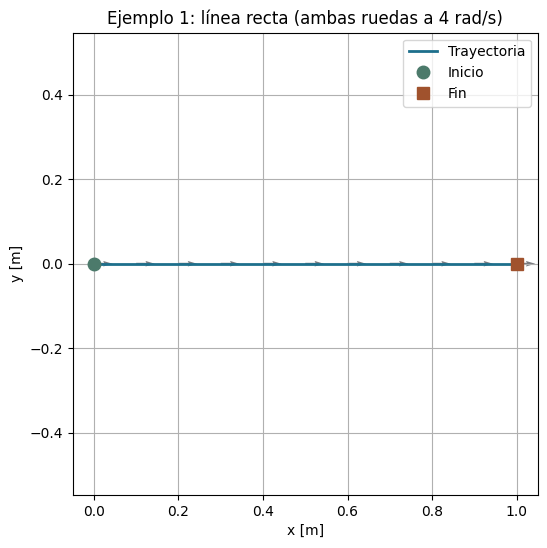

v obtenido = 0.200 m/s,  omega obtenido = 0.000 rad/s


In [ ]:
theta_dot_r_recta = lambda t: 4.0
theta_dot_l_recta = lambda t: 4.0

t, x, y, phi, v_hist, omega_hist, tdr, tdl = simular_robot_diferencial(
    theta_dot_r_recta, theta_dot_l_recta, R_RUEDA, B_SEMIDIST,
    estado_inicial=(0, 0, 0), dt=0.05, t_final=5.0
)

graficar_trayectoria(x, y, phi, titulo="Ejemplo 1: línea recta (ambas ruedas a 4 rad/s)")
print(f"v obtenido = {v_hist[0]:.3f} m/s,  omega obtenido = {omega_hist[0]:.3f} rad/s")


## 8. Ejemplo 2 — Ruedas con velocidades distintas: trayectoria circular

Si $\dot\theta_r \neq \dot\theta_l$ pero ambas son constantes, el robot describe una circunferencia de radio $R = v/\omega$.

**Pregunta para el aula:** a partir de la fórmula de $\omega$, ¿qué le ocurre al radio de giro si se acerca $\dot\theta_l$ a $\dot\theta_r$? ¿Y si $\dot\theta_l = \dot\theta_r$ exactamente?


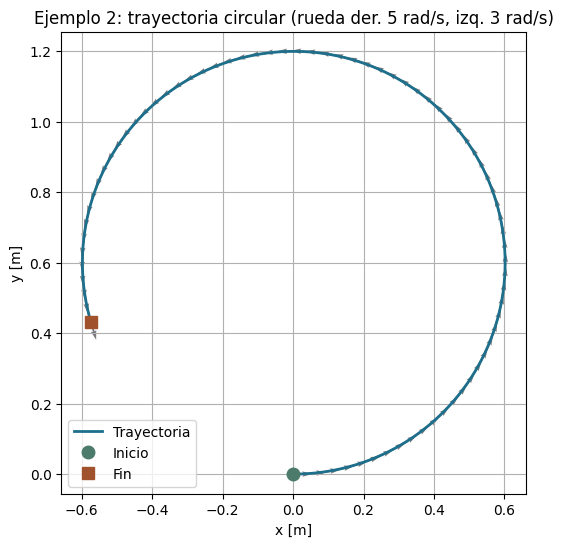

v = 0.200 m/s,  omega = 0.333 rad/s,  R = v/omega = 0.600 m


In [ ]:
theta_dot_r_circulo = lambda t: 5.0
theta_dot_l_circulo = lambda t: 3.0

t, x, y, phi, v_hist, omega_hist, tdr, tdl = simular_robot_diferencial(
    theta_dot_r_circulo, theta_dot_l_circulo, R_RUEDA, B_SEMIDIST,
    estado_inicial=(0, 0, 0), dt=0.02, t_final=15.0
)

graficar_trayectoria(x, y, phi, titulo="Ejemplo 2: trayectoria circular (rueda der. 5 rad/s, izq. 3 rad/s)")

v_teorico, omega_teorico = diferencial_a_v_omega(5.0, 3.0, R_RUEDA, B_SEMIDIST)
radio_teorico = v_teorico / omega_teorico
print(f"v = {v_teorico:.3f} m/s,  omega = {omega_teorico:.3f} rad/s,  R = v/omega = {radio_teorico:.3f} m")


## 9. Ejemplo 3 — Giro sobre el propio eje

Si las ruedas giran a la misma velocidad pero en sentidos opuestos ($\dot\theta_r = -\dot\theta_l$), entonces $v = 0$ y $\omega \neq 0$: el robot gira sobre su propio eje, con radio de giro nulo. Esta es, precisamente, la maniobra que un vehículo con dirección Ackerman **no puede** ejecutar (ver lectura, sección 6.2).


In [ ]:
theta_dot_r_spin = lambda t: 3.0
theta_dot_l_spin = lambda t: -3.0

t, x, y, phi, v_hist, omega_hist, tdr, tdl = simular_robot_diferencial(
    theta_dot_r_spin, theta_dot_l_spin, R_RUEDA, B_SEMIDIST,
    estado_inicial=(0, 0, 0), dt=0.02, t_final=6.0
)

print(f"v = {v_hist[0]:.4f} m/s (debería ser ≈ 0)")
print(f"Posición final: x = {x[-1]:.4f} m, y = {y[-1]:.4f} m (debería seguir ≈ (0,0))")
print(f"Orientación final: {np.degrees(phi[-1]):.1f}°")


v = 0.0000 m/s (debería ser ≈ 0)
Posición final: x = 0.0000 m, y = 0.0000 m (debería seguir ≈ (0,0))
Orientación final: 343.8°


## 10. Ejemplo 4 — Velocidades de rueda variables en el tiempo

Aquí $\dot\theta_r(t)$ y $\dot\theta_l(t)$ ya no son constantes. Esto ilustra que el modelo admite **cualquier** perfil de velocidades de rueda, siempre que se integre numéricamente: no existe una fórmula cerrada que dé la posición final directamente a partir de perfiles arbitrarios.


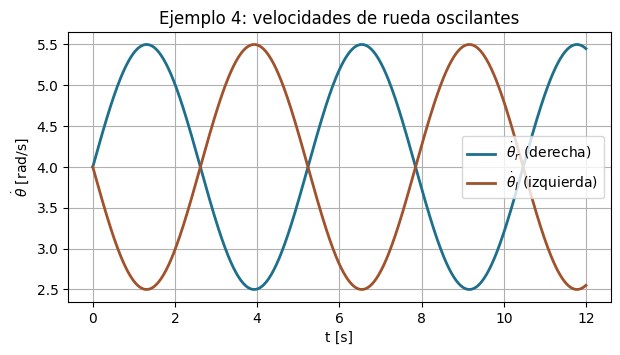

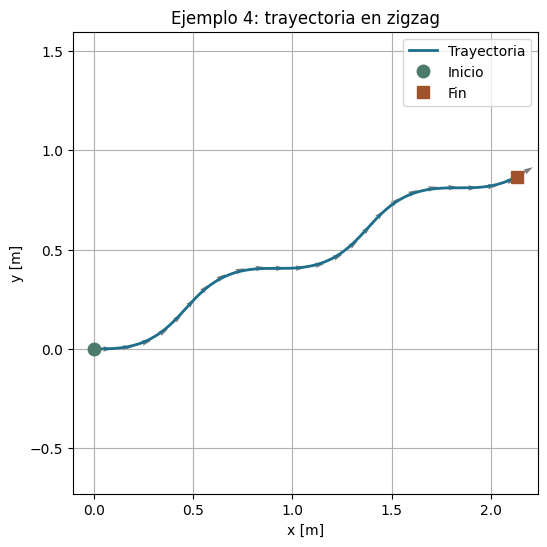

In [ ]:
theta_dot_r_var = lambda t: 4.0 + 1.5 * np.sin(1.2 * t)
theta_dot_l_var = lambda t: 4.0 - 1.5 * np.sin(1.2 * t)

t, x, y, phi, v_hist, omega_hist, tdr, tdl = simular_robot_diferencial(
    theta_dot_r_var, theta_dot_l_var, R_RUEDA, B_SEMIDIST,
    estado_inicial=(0, 0, 0), dt=0.02, t_final=12.0
)

graficar_velocidades_rueda(t, tdr, tdl, titulo="Ejemplo 4: velocidades de rueda oscilantes")
graficar_trayectoria(x, y, phi, titulo="Ejemplo 4: trayectoria en zigzag", cada=25)


## 11. Ejemplo 5 — Maniobra por tramos: avanzar y girar en el sitio

Se combinan tramos de avance en línea recta (ambas ruedas iguales) con tramos de giro en el sitio (ruedas opuestas), para trazar aproximadamente un cuadrado — la misma lógica que se usaría para programar un recorrido punto a punto con un robot real.


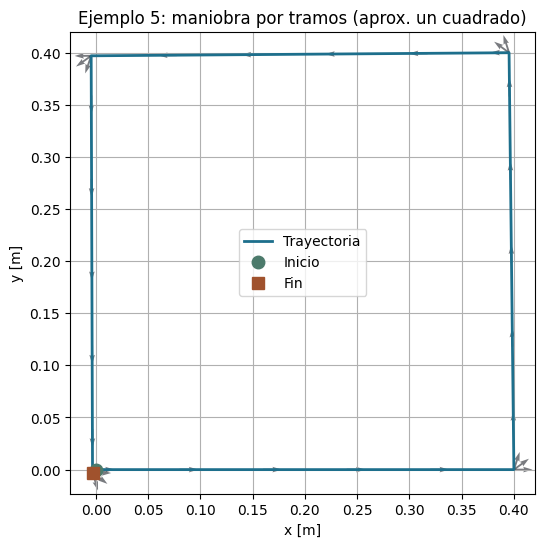

In [ ]:
def theta_dot_r_cuadrado(t):
    fase = t % 3.0
    return 4.0 if fase < 2.0 else 4.7   # avanza 2 s, gira 1 s

def theta_dot_l_cuadrado(t):
    fase = t % 3.0
    return 4.0 if fase < 2.0 else -4.7  # avanza 2 s, gira 1 s (sentido opuesto)

t, x, y, phi, v_hist, omega_hist, tdr, tdl = simular_robot_diferencial(
    theta_dot_r_cuadrado, theta_dot_l_cuadrado, R_RUEDA, B_SEMIDIST,
    estado_inicial=(0, 0, 0), dt=0.01, t_final=12.0
)

graficar_trayectoria(x, y, phi, titulo="Ejemplo 5: maniobra por tramos (aprox. un cuadrado)", cada=40)


## 12. Ejercicios propuestos

Resuelve los siguientes ejercicios modificando el código anterior. No hay una única celda "correcta": el objetivo es experimentar con el modelo.

1. **Efecto del paso de integración.** Repite el Ejemplo 2 (círculo) con `dt = 0.5` en lugar de `0.02`. ¿La trayectoria sigue siendo un círculo suave? Explica, en tus propias palabras, por qué la integración de Euler pierde precisión al aumentar `dt`.
2. **Problema inverso.** Se desea que el robot avance con $v = 0.3$ m/s describiendo un giro de radio $R = 1$ m. Calcula qué valores de $\dot\theta_r$ y $\dot\theta_l$ deben comandarse (a partir de las fórmulas de la sección 3, no por prueba y error) y verifica el resultado simulándolo.
3. **Efecto de la geometría del robot.** Repite el Ejemplo 2 duplicando el valor de `B_SEMIDIST` (es decir, separando más las ruedas) sin cambiar las velocidades de rueda. ¿El radio de giro aumenta o disminuye? Justifica el resultado a partir de la fórmula de $\omega$.
4. **Discusión abierta (para la siguiente clase).** Todo lo simulado en este notebook asume que ambas ruedas ruedan sin deslizar sobre el suelo. ¿Qué ecuación de la lectura previa expresa esa condición para una sola rueda? ¿Qué esperarías que ocurra con la trayectoria calculada si, en la realidad, una rueda patinara durante un giro brusco?


theta_dot_r = 6.900 rad/s,  theta_dot_l = 5.100 rad/s


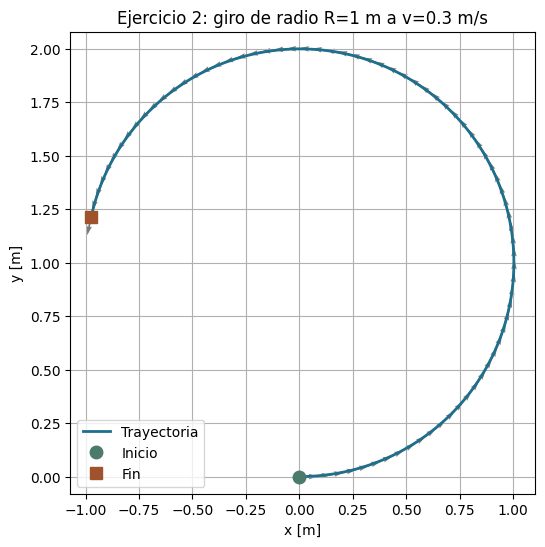

Verificación: v = 0.300 m/s, R = v/omega = 1.000 m


In [ ]:
# Espacio de trabajo para los ejercicios propuestos.
# Ejercicio 2 — completa el cálculo:

v_deseado = 0.3      # m/s
R_deseado = 1.0       # m
omega_deseado = v_deseado / R_deseado

# A partir de v = r(theta_dot_r + theta_dot_l)/2  y  omega = r(theta_dot_r - theta_dot_l)/(2b),
# despejando theta_dot_r y theta_dot_l:
theta_dot_r_ej2 = (v_deseado + omega_deseado * B_SEMIDIST) / R_RUEDA
theta_dot_l_ej2 = (v_deseado - omega_deseado * B_SEMIDIST) / R_RUEDA

print(f"theta_dot_r = {theta_dot_r_ej2:.3f} rad/s,  theta_dot_l = {theta_dot_l_ej2:.3f} rad/s")

t, x, y, phi, v_hist, omega_hist, tdr, tdl = simular_robot_diferencial(
    lambda t: theta_dot_r_ej2, lambda t: theta_dot_l_ej2, R_RUEDA, B_SEMIDIST,
    estado_inicial=(0, 0, 0), dt=0.02, t_final=15.0
)
graficar_trayectoria(x, y, phi, titulo="Ejercicio 2: giro de radio R=1 m a v=0.3 m/s")

v_verif, omega_verif = diferencial_a_v_omega(theta_dot_r_ej2, theta_dot_l_ej2, R_RUEDA, B_SEMIDIST)
print(f"Verificación: v = {v_verif:.3f} m/s, R = v/omega = {v_verif/omega_verif:.3f} m")
